In [37]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score,roc_curve,confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import seaborn as sns

In [38]:
data = pd.read_csv("fraud_dataset_1000.csv")

print("Shape:", data.shape)
data.head()
print(data.dtypes)

Shape: (1000, 11)
Transaction_ID                        int64
User_ID                               int64
Transaction_Amount                  float64
Account_Age_Months                    int64
Number_of_Transactions_Last_24H       int64
Previous_Fraudulent_Transactions      int64
Device_Used                             str
Location                                str
Payment_Method                          str
Transaction_Type                        str
Fraudulent                            int64
dtype: object


In [39]:
le = LabelEncoder()
data["Device_Used_EN"] = le.fit_transform(data["Device_Used"])
data["Location_EN"] = le.fit_transform(data["Location"])
data["Payment_Method_EN"] = le.fit_transform(data["Payment_Method"])
data["Transaction_Type_EN"] = le.fit_transform(data["Transaction_Type"])

In [40]:
data.dtypes

Transaction_ID                        int64
User_ID                               int64
Transaction_Amount                  float64
Account_Age_Months                    int64
Number_of_Transactions_Last_24H       int64
Previous_Fraudulent_Transactions      int64
Device_Used                             str
Location                                str
Payment_Method                          str
Transaction_Type                        str
Fraudulent                            int64
Device_Used_EN                        int64
Location_EN                           int64
Payment_Method_EN                     int64
Transaction_Type_EN                   int64
dtype: object

In [41]:
feature_cols = [
    "Transaction_Amount",
    "Previous_Fraudulent_Transactions",
    "Number_of_Transactions_Last_24H",
    "Device_Used_EN",
    "Location_EN",
    "Payment_Method_EN",
    "Transaction_Type_EN"
]

X = data[feature_cols]
y = data["Fraudulent"]

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (800, 7)
Test shape: (200, 7)


In [43]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [44]:
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train, y_train
)

print("Before SMOTE:", np.bincount(y_train))
print("After SMOTE:", np.bincount(y_train_resampled))

Before SMOTE: [771  29]
After SMOTE: [771 771]


In [45]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train_resampled, y_train_resampled)

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:,1]

print("XGBoost")
print(classification_report(y_test, xgb_pred))
print("ROC-AUC:", roc_auc_score(y_test, xgb_prob))

XGBoost
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       193
           1       0.33      0.14      0.20         7

    accuracy                           0.96       200
   macro avg       0.65      0.57      0.59       200
weighted avg       0.95      0.96      0.95       200

ROC-AUC: 0.8956328645447816


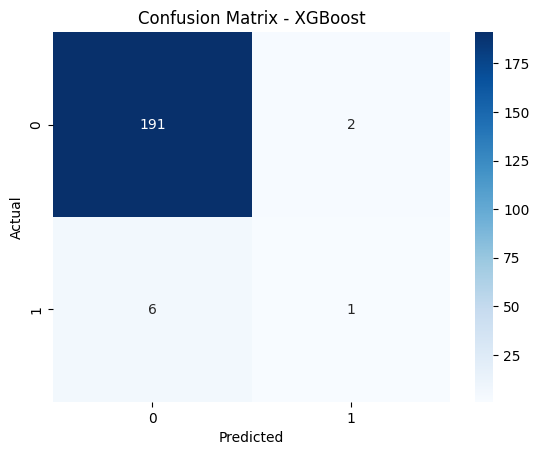

In [46]:
cm = confusion_matrix(y_test, xgb_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")
plt.show()

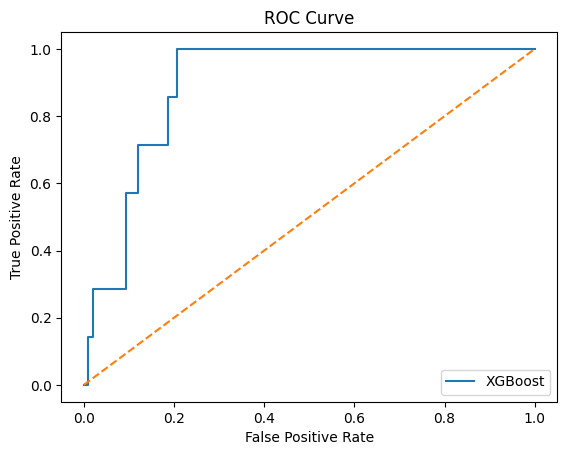

In [47]:
fpr, tpr, _ = roc_curve(y_test, xgb_prob)

plt.plot(fpr, tpr, label="XGBoost")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [48]:
joblib.dump(xgb_model, "fraud_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model and scaler saved successfully!")

Model and scaler saved successfully!
